In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

from data_loader import (
    fetch_prices,
    compute_returns,
    describe_returns,
    jarque_bera,
    TICKERS,
    START_DATE,
    END_DATE,
)

from dcc_garch import (
    fit_univariate_garch,
    fit_dcc,
    get_dynamic_covariance,
)

from portfolio import (
    hrp_weights,
    benchmark_equal_weights,
    benchmark_static_hrp,
    benchmark_min_variance,
)

from evaluation import (
    sharpe_ratio,
    max_drawdown,
    calmar_ratio,
    metrics_table,
)

from plots import (
    plot_paired_correlation,
    plot_rolling_correlation,
    plot_dynamic_correlations,
    plot_dendogram,
)

In [2]:
prices = fetch_prices()
returns = compute_returns(prices)

print(f"Liczba aktywów: {len(TICKERS)}")
print(f"Zakres dat: {START_DATE} -> {END_DATE}")
print(f"Wymiary cen: {prices.shape}")
print(f"Wymiary zwrotów: {returns.shape}")
print(f"Pierwsza dostępna data zwrotów: {returns.index[0].date()}")
print(f"Ostatnia dostępna data zwrotów: {returns.index[-1].date()}")

Loading data from cache: ../data/prices.parquet
Liczba aktywów: 16
Zakres dat: 2011-10-10 -> 2026-01-01
Wymiary cen: (3578, 16)
Wymiary zwrotów: (3577, 16)
Pierwsza dostępna data zwrotów: 2011-10-11
Ostatnia dostępna data zwrotów: 2025-12-31


In [3]:
prices.tail()

Ticker,AGG,GLD,HYG,IEF,IWM,LQD,QQQ,SPY,SVXY,TIP,TLT,XLE,XLF,XLK,XLU,XLV
Date,,,,,,,,,,,,,,,,
2025-12-24,98.3876,411.9300,78.6495,94.8091,252.2613,108.5753,623.1443,688.4997,54.9300,108.2481,86.3960,44.0820,55.4450,146.1183,42.5128,155.1621
2025-12-26,98.4073,416.7400,78.6104,94.8977,250.9736,108.5655,623.1043,688.4299,55.0000,108.2383,86.1114,43.9131,55.3356,146.3480,42.4830,155.4111
2025-12-29,98.5253,398.6000,78.6397,95.0355,249.4363,108.7127,620.0881,685.9766,55.3700,108.3366,86.4352,44.3304,55.0371,145.6889,42.5624,155.1721
2025-12-30,98.4860,398.8900,78.7177,94.9370,247.5896,108.5851,618.6499,685.1389,55.6900,108.3170,86.2291,44.6682,54.8978,145.2294,42.6617,155.0426
2025-12-31,98.2499,396.3100,78.6397,94.6222,245.7229,108.1239,613.5364,680.0627,55.3800,108.1006,85.5421,44.4198,54.4899,143.7912,42.3936,154.1662


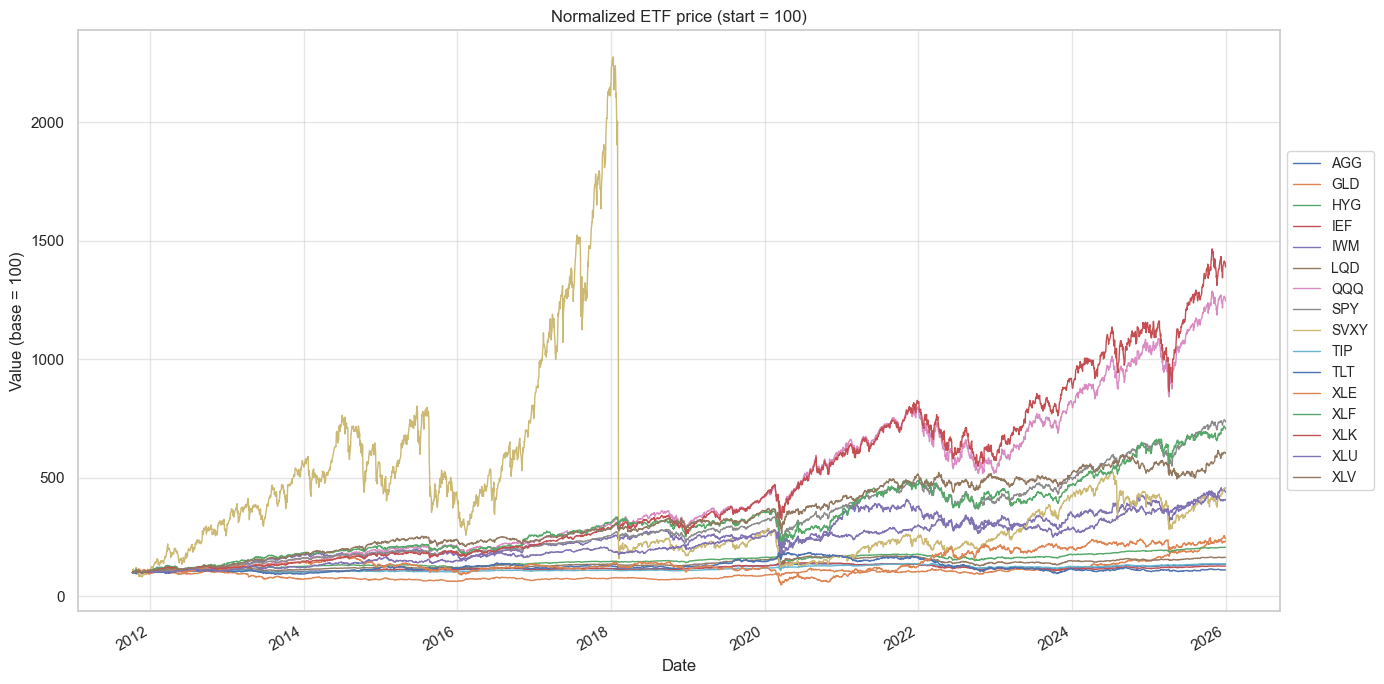

In [4]:
# Price normalization for better comparison
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.plot(figsize=(14, 7), linewidth=1)
plt.title("Normalized ETF price (start = 100)")
plt.xlabel("Date")
plt.ylabel("Value (base = 100)")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize="small")
plt.tight_layout()
plt.show()

In [5]:
describe_returns(returns)

            count   mean    std     min     25%    50%    75%    max
Ticker                                                              
AGG    3,577.0000 0.0001 0.0030 -0.0408 -0.0013 0.0002 0.0016 0.0234
GLD    3,577.0000 0.0002 0.0098 -0.0919 -0.0048 0.0005 0.0054 0.0479
HYG    3,577.0000 0.0002 0.0051 -0.0565 -0.0018 0.0002 0.0023 0.0634
IEF    3,577.0000 0.0001 0.0041 -0.0254 -0.0023 0.0002 0.0025 0.0261
IWM    3,577.0000 0.0004 0.0136 -0.1423 -0.0066 0.0009 0.0079 0.0875
LQD    3,577.0000 0.0001 0.0049 -0.0513 -0.0021 0.0004 0.0025 0.0713
QQQ    3,577.0000 0.0007 0.0130 -0.1276 -0.0047 0.0012 0.0074 0.1134
SPY    3,577.0000 0.0006 0.0106 -0.1159 -0.0036 0.0007 0.0057 0.0999
SVXY   3,577.0000 0.0004 0.0445 -1.7695 -0.0102 0.0041 0.0171 0.1254
TIP    3,577.0000 0.0001 0.0035 -0.0291 -0.0017 0.0002 0.0020 0.0436
TLT    3,577.0000 0.0000 0.0093 -0.0690 -0.0056 0.0005 0.0056 0.0725
XLE    3,577.0000 0.0002 0.0173 -0.2249 -0.0077 0.0006 0.0087 0.1487
XLF    3,577.0000 0.0005 0.0133 -0

In [6]:
jarque_bera(returns)

=== JB Test Summary ===
100.0% of the ETFs completely reject the assumption of normality (p < 0.05).


In [ ]:
# Wysoki odsetek odrzuceń normalności (JB) oraz istotna kurtoza
# potwierdzają zasadność użycia rozkładu t-Studenta w modelach GARCH
# zamiast standardowego rozkładu normalnego.

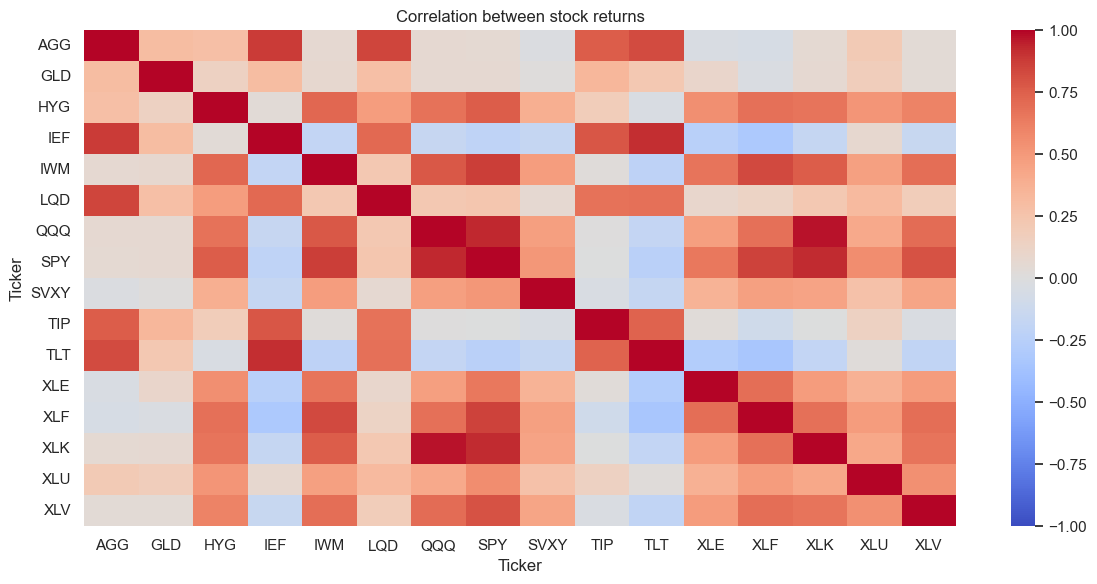

In [8]:
plot_paired_correlation(returns)

In [ ]:
Powyższa macierz to korelacja statyczna (uśredniona po całym okresie).
W kolejnych sekcjach sprawdzimy, jak bardzo te korelacje zmieniają się
w czasie (rolling correlation, DCC-GARCH) - to główne uzasadnienie
całego podejścia zamiast klasycznego, statycznego Markowitza.

In [ ]:
# ============================================================
# SECTION 2: GARCH Diagnostics (univariate)
# ============================================================
# We check if the univariate GARCH(1,1) models correctly found
# ARCH effects in the returns, before we use standardized
# residuals as inputs in the DCC model.

In [9]:
std_resid, vols = fit_univariate_garch(returns)

print(f"Shape of std_resid: {std_resid.shape}")
print(f"Shape of  vols: {vols.shape}")
std_resid.describe().T[["mean", "std"]]

Wymiary std_resid: (3577, 16)
Wymiary vols: (3577, 16)


,mean,std
AGG,-0.0232,1.0030
GLD,-0.0057,0.9942
HYG,-0.0527,0.9960
IEF,-0.0047,1.0017
IWM,-0.0386,1.0003
LQD,-0.0325,1.0018
QQQ,-0.0720,0.9888
SPY,-0.0702,0.9948
SVXY,-0.1136,1.0115
TIP,-0.0167,1.0004


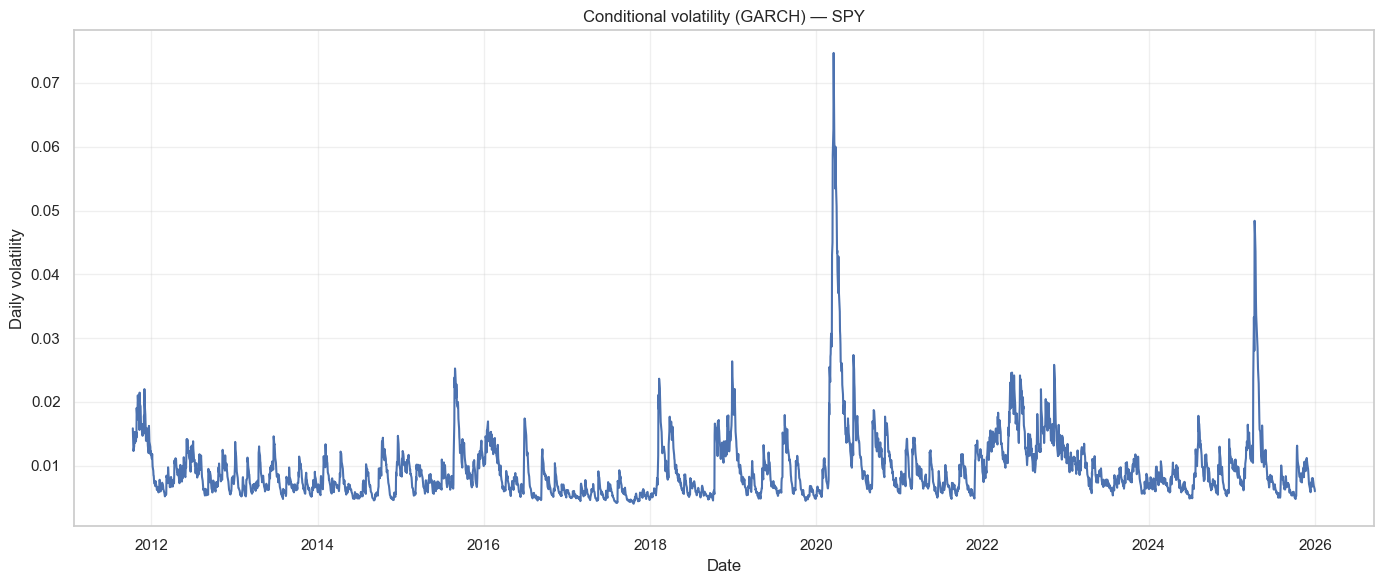

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(vols.index, vols["SPY"])
plt.title("Conditional volatility (GARCH) — SPY")
plt.xlabel("Date")
plt.ylabel("Daily volatility`")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

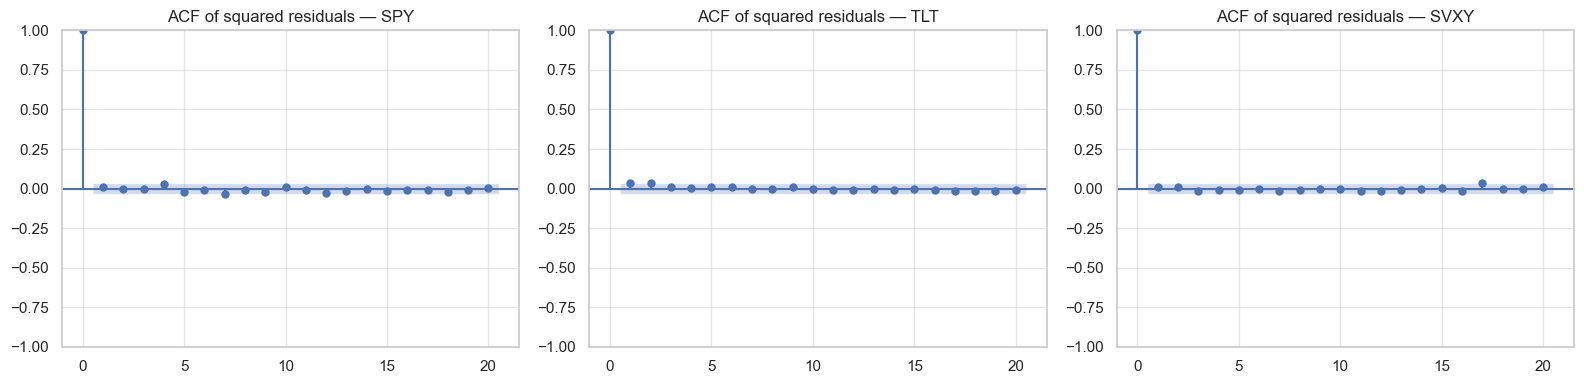

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

assets_to_check = ["SPY", "TLT", "SVXY"]

fig, axes = plt.subplots(1, len(assets_to_check), figsize=(16, 4))

for ax, asset in zip(axes, assets_to_check):
    squared_resid = std_resid[asset] ** 2
    plot_acf(squared_resid, ax=ax, lags=20, title=f"ACF of squared residuals — {asset}")

plt.tight_layout()
plt.show()

In [14]:
from arch import arch_model

garch_params = {}

for asset in returns.columns:
    y = returns[asset].dropna()
    current_variance = np.var(y)
    rescale_factor = 1.0 / np.sqrt(current_variance) if current_variance > 0 else 1.0
    y_scaled = y * rescale_factor

    model = arch_model(y_scaled, p=1, q=1, dist='t')
    res = model.fit(disp="off", show_warning=False)

    garch_params[asset] = {
        "omega": res.params["omega"],
        "alpha[1]": res.params["alpha[1]"],
        "beta[1]": res.params["beta[1]"],
        "alpha+beta": res.params["alpha[1]"] + res.params["beta[1]"],
    }

garch_params_df = pd.DataFrame(garch_params).T
garch_params_df

,omega,alpha[1],beta[1],alpha+beta
AGG,0.0110,0.0878,0.8991,0.9869
GLD,0.0124,0.0417,0.9470,0.9887
HYG,0.0105,0.1662,0.8326,0.9988
IEF,0.0097,0.0571,0.9329,0.9900
IWM,0.0195,0.0963,0.8838,0.9801
LQD,0.0116,0.0797,0.9046,0.9843
QQQ,0.0190,0.1417,0.8494,0.9911
SPY,0.0238,0.1741,0.8119,0.9860
SVXY,0.0335,0.3214,0.6786,1.0000
TIP,0.0195,0.0800,0.8977,0.9776


In [ ]:
# Note:
# SVXY stands out as the only ETF with alpha+beta ~= 1.0 (close to IGARCH),
# suggesting highly persistent (non-mean-reverting) volatility shocks.
# This is consistent with the nature of the instrument (a short-VIX ETF),
# which experienced a severe "blow-up" in February 2018.